In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

from src.common.load_data import load_data, drop_targets, get_test_sets
from src.common.treat_missing import load_and_process_for_random_forest
from src.common.evaluations import evaluate_classification
from src.utils.plots import plot_loss_curve, plot_roc_auc_curve, plot_precision_recall_curve

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore")
pd.options.display.max_rows = 200

**How to fix overfitting in Random Forest?**

| If your model is overfitting | Action to take on Hyperparameter |
|---|---|
| max_depth | Decrease it (e.g., from None to 10)|
| min_samples_leaf | Increase it (e.g., from 1 to 5) |
| min_samples_split | Increase it (e.g., from 2 to 10) |
| max_features | Decrease it (e.g., from 1.0 to 'sqrt') | 
| ccp_alpha | Increase it (e.g., from 0.0 to 0.01) |

## 1. Load Data

In [3]:
df = load_data("./data/cibil_score/cibil_score.csv")
X, y_lin_reg, y_binary, y_multiclass = drop_targets(df)
X_train, X_test, y_train, y_test = get_test_sets(X, y_binary, test_size=0.3)

0


## 2. Preprocessing

In [4]:
X_train_processed, X_test_processed = load_and_process_for_random_forest(X_train, X_test)

2026-09-02 09:12:28,302 [INFO] src.common.treat_missing: No columns exceeded the 95% null threshold; none dropped.
2026-09-02 09:12:28,385 [INFO] src.common.treat_missing: Fitted OrdinalEncoder on 5 categorical column(s): ['maritalstatus', 'education', 'gender', 'last_prod_enq2', 'first_prod_enq2']
2026-09-02 09:12:28,385 [INFO] src.common.treat_missing: TreeModelPreprocessor fit complete.
2026-09-02 09:12:28,508 [INFO] src.common.treat_missing: Random-forest data processing complete (no validation split; use oob_score=True for held-out estimates).


## 3. Random Forest Binary Classification

In [11]:
# max_depth = None gets stuck for very much long time, max_depth=None, max_features=1.0, min_samples_leaf=1, min_samples_split=2, ccp_alpha=0.0, n_estimators=500
# min_samples_split = 1 also stuck more than 2 mins., max_features reduced from 1.0 to 0.7
model = RandomForestClassifier(max_depth=30, max_features=0.7, min_samples_leaf=2, min_samples_split=2, ccp_alpha=0.0, n_estimators=500)
model.fit(X_train_processed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.7
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tr

In [ ]:
rf_binary = Pipeline(
    steps=[
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            min_samples_split=5,
            min_samples_leaf=2,
            max_features="sqrt",
            random_state=42,
        ))
    ]
)
rf_binary.fit(
    X_train_processed,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](85,)","['prospectid','total_tl','tot_closed_tl',...,'gl_flag','last_prod_enq2', 'first_prod_enq2']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,85
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5


## 4. Evaluate Binary Classification

In [7]:
evaluate_classification(rf_binary, X_test_processed, y_test, binary=True)

              precision    recall  f1-score   support

           0       0.84      0.69      0.76      2059
           1       0.89      0.95      0.92      5642

    accuracy                           0.88      7701
   macro avg       0.87      0.82      0.84      7701
weighted avg       0.88      0.88      0.88      7701



{'accuracy': 0.8817036748474224,
 'f1_macro': 0.8391208512703312,
 'precision_macro': 0.8672708021923269,
 'recall_macro': 0.8197973672444524,
 'precision_weighted': 0.879183491140313,
 'recall_weighted': 0.8817036748474224,
 'f1_weighted': 0.8776302548232634,
 'confusion_matrix': array([[1414,  645],
        [ 266, 5376]]),
 'roc_auc': 0.9359764301561917}

## 5. Random Search for Best Parameters

In [14]:
# max_depth = None gets stuck for very much long time, max_depth=None, max_features=1.0, min_samples_leaf=1, min_samples_split=2, ccp_alpha=0.0, n_estimators=500
# min_samples_split = 1 also stuck more than 2 mins., max_features reduced from 1.0 to 0.7
# model = RandomForestClassifier(max_depth=30, max_features=0.7, min_samples_leaf=2, min_samples_split=2, ccp_alpha=0.0, n_estimators=500)
# model.fit(X_train_processed, y_train)
# Above single training took 5 mins so for 250 fits with 3 workers(assigned on local machine) will take 7 hours, so reducing search parameters

param_distributions = {
    "model__n_estimators": [100, 200, 300], # dropped 400, 500
    "model__max_depth": [5, 8, 10, 12, 15, 20], # dropped None and 30 
    "model__min_samples_split": [5, 10, 15, 20], # dropped 2
    "model__min_samples_leaf": [2, 4, 6, 8], # dropped 1
    "model__max_features": ["sqrt", "log2", 0.3, 0.5, 0.7], # dropped 1.0
    "model__ccp_alpha": [0.001, 0.01, 0.05], # dropped 0.0
}

rf_search_base = Pipeline(
    steps=[
        ("model", RandomForestClassifier(random_state=RANDOM_STATE))
    ]
)


## 6. Random Search for Best Parameters

In [16]:
rf_random_search = RandomizedSearchCV(
    estimator=rf_search_base,
    param_distributions=param_distributions,
    n_iter=20, # drop from 50
    scoring="roc_auc",
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE), # drop from 5
    verbose=3,
    random_state=RANDOM_STATE,
    n_jobs=-2
)

rf_random_search.fit(X_train_processed, y_train)

print("Best Parameters:")
for param, value in rf_random_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV Score (ROC-AUC): {rf_random_search.best_score_:.4f}")


Fitting 3 folds for each of 20 candidates, totalling 60 fits


[CV 1/3] END model__ccp_alpha=0.001, model__max_depth=12, model__max_features=0.3, model__min_samples_leaf=8, model__min_samples_split=15, model__n_estimators=300;, score=0.926 total time=  53.9s
[CV 2/3] END model__ccp_alpha=0.001, model__max_depth=12, model__max_features=0.3, model__min_samples_leaf=8, model__min_samples_split=15, model__n_estimators=300;, score=0.921 total time=  54.4s
[CV 3/3] END model__ccp_alpha=0.001, model__max_depth=12, model__max_features=0.3, model__min_samples_leaf=8, model__min_samples_split=15, model__n_estimators=300;, score=0.925 total time=  54.1s
[CV 1/3] END model__ccp_alpha=0.05, model__max_depth=12, model__max_features=0.5, model__min_samples_leaf=6, model__min_samples_split=10, model__n_estimators=200;, score=0.815 total time= 1.2min
[CV 2/3] END model__ccp_alpha=0.05, model__max_depth=12, model__max_features=0.5, model__min_samples_leaf=6, model__min_samples_split=10, model__n_estimators=200;, score=0.810 total time= 1.2min
[CV 3/3] END model__cc

## 7. Run Regression Using Best Parameters

In [17]:
# Strip the pipeline step prefix ("model__") so the params can be passed
# straight into a fresh RandomForestClassifier
best_params = {
    k.replace("model__", ""): v for k, v in rf_random_search.best_params_.items()
}

rf_best = Pipeline(
    steps=[
        ("model", RandomForestClassifier(
            **best_params,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ))
    ]
)

rf_best.fit(X_train_processed, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](85,)","['prospectid','total_tl','tot_closed_tl',...,'gl_flag','last_prod_enq2', 'first_prod_enq2']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,85
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",15


## 8. Plot Train and Test Loss Curve - Model with best parameters

n_estimators evaluated at each step: [15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165, 180, 195, 210, 225, 240, 255, 270, 285, 300]


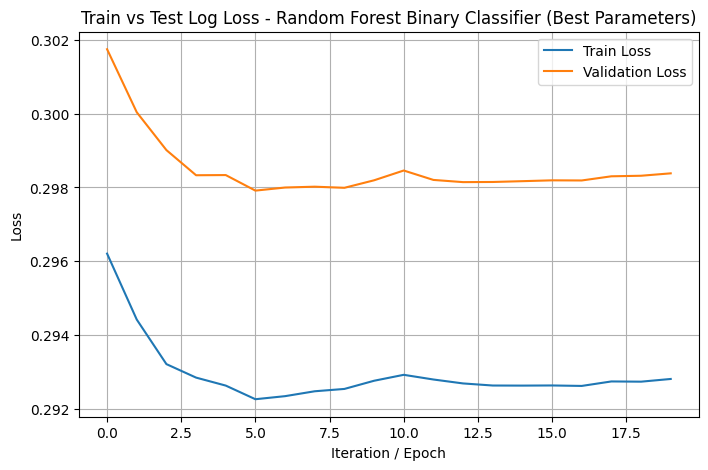

In [18]:
from sklearn.metrics import log_loss

# RandomForestClassifier has no staged/iterative loss the way boosting models
# do, so we track train/test log loss as trees are added using `warm_start`,
# then hand the two loss lists to the shared `plot_loss_curve` helper.
warm_start_params = {k: v for k, v in best_params.items() if k != "n_estimators"}
target_n_estimators = best_params.get("n_estimators", 200)

step = max(target_n_estimators // 20, 1)
n_estimators_range = list(range(step, target_n_estimators + step, step))

rf_warm = RandomForestClassifier(
    **warm_start_params,
    warm_start=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

train_losses = []
test_losses = []

for n_est in n_estimators_range:
    rf_warm.set_params(n_estimators=n_est)
    rf_warm.fit(X_train_processed, y_train)
    train_proba = rf_warm.predict_proba(X_train_processed)
    test_proba = rf_warm.predict_proba(X_test_processed)
    train_losses.append(log_loss(y_train, train_proba, labels=rf_warm.classes_))
    test_losses.append(log_loss(y_test, test_proba, labels=rf_warm.classes_))

print(f"n_estimators evaluated at each step: {n_estimators_range}")

plot_loss_curve(
    train_losses,
    test_losses,
    title="Train vs Test Log Loss - Random Forest Binary Classifier (Best Parameters)",
)


### Todo: Explain Graph

## 9. Plot ROC-AUC Curve - Model with best parameters

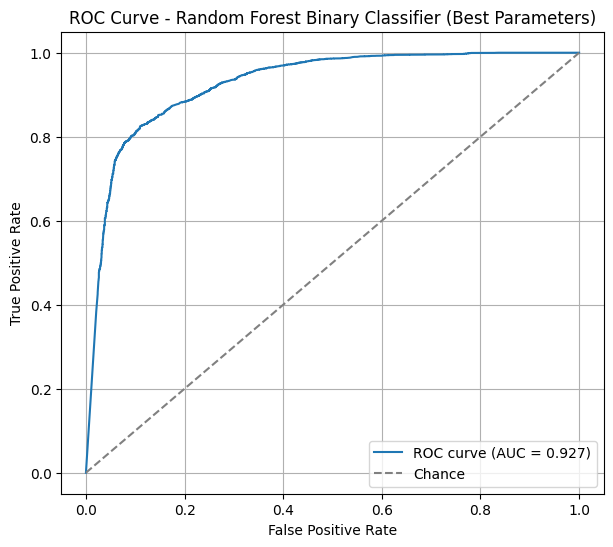

In [19]:
# Positive class = the second entry in classes_ (sklearn's convention);
# swap the column index below if your positive class is encoded differently.
positive_class = rf_best.classes_[1]
y_test_scores = rf_best.predict_proba(X_test_processed)[:, 1]

plot_roc_auc_curve(
    y_test,
    y_test_scores,
    pos_label=positive_class,
    title="ROC Curve - Random Forest Binary Classifier (Best Parameters)",
)


### Todo: Explain Graph

## 10. Plot Precision-Recall Curve - Model with best parameters

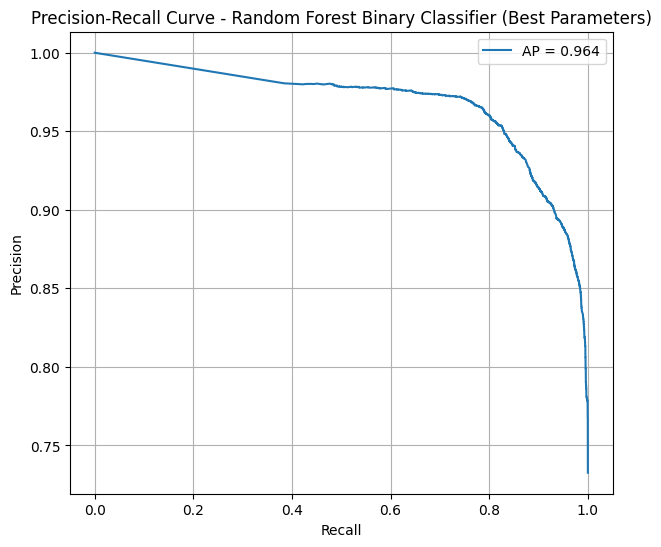

In [20]:
plot_precision_recall_curve(
    y_test,
    y_test_scores,
    pos_label=positive_class,
    title="Precision-Recall Curve - Random Forest Binary Classifier (Best Parameters)",
)


### Todo: Explain Graph

## 11. Evaluate Binary Classification - Model with best parameters

In [21]:
binary_results_best = evaluate_classification(
    rf_best,
    X_test_processed,
    y_test,
    binary=True
)

print("\n==============================")
print("Random Forest Binary Classification - Best Parameters")
print("==============================")

for metric, value in binary_results_best.items():
    print(f"{metric}: {value}")


              precision    recall  f1-score   support

           0       0.85      0.66      0.74      2059
           1       0.88      0.96      0.92      5642

    accuracy                           0.88      7701
   macro avg       0.87      0.81      0.83      7701
weighted avg       0.88      0.88      0.87      7701


Random Forest Binary Classification - Best Parameters
accuracy: 0.8771588105440852
f1_macro: 0.8302906465440367
precision_macro: 0.8667213091188378
recall_macro: 0.8074427139546443
precision_weighted: 0.8750116145071466
recall_weighted: 0.8771588105440852
f1_weighted: 0.8717852429394343
confusion_matrix: [[1354  705]
 [ 241 5401]]
roc_auc: 0.926647977193184


## 12. Feature Importance

Top 20 features by impurity-based importance:
                         feature  importance
0                        enq_l3m    0.399470
1                  age_oldest_tl    0.144414
2   time_since_recent_deliquency    0.112988
3                        enq_l6m    0.083933
4          time_since_recent_enq    0.063523
5         pct_pl_enq_l6m_of_ever    0.044317
6                  num_std_12mts    0.043708
7                        num_std    0.028171
8    time_since_first_deliquency    0.022742
9         pct_pl_enq_l6m_of_l12m    0.017156
10                  num_std_6mts    0.006391
11               max_deliq_12mts    0.006107
12              pct_tl_open_l12m    0.004282
13         max_delinquency_level    0.003764
14     max_recent_level_of_deliq    0.003508
15         recent_level_of_deliq    0.003302
16          num_times_delinquent    0.003118
17                    pl_enq_l6m    0.002704
18                      total_tl    0.002686
19                max_deliq_6mts    0.000638


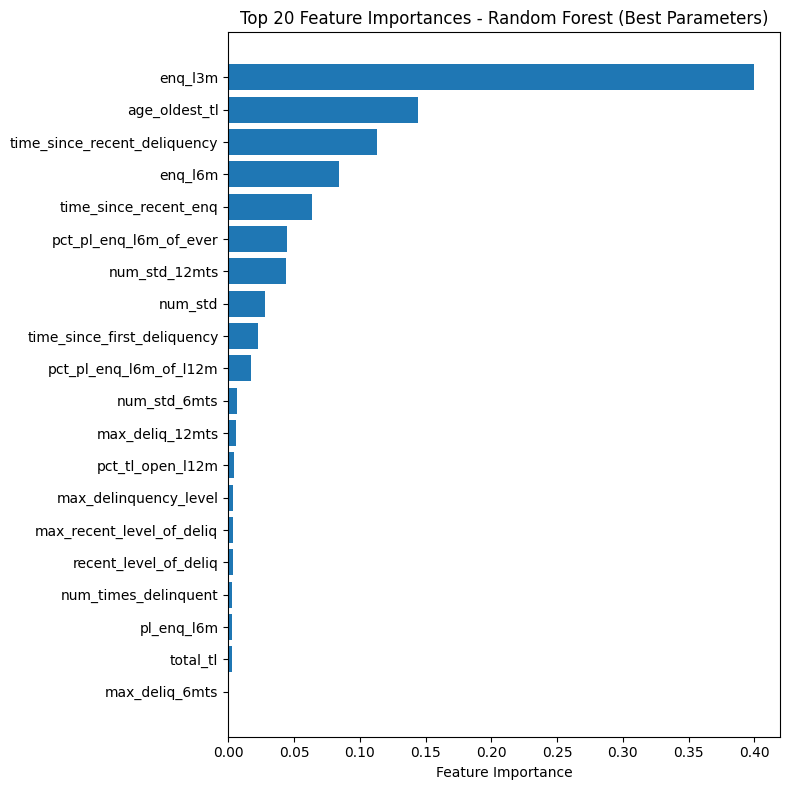

/home/neeraj/Projects/ml_course/ml_env/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/neeraj/Projects/ml_course/ml_env/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/neeraj/Projects/ml_course/ml_env/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/neeraj/Projects/ml_


Top 20 features by permutation importance:
                         feature  importance_mean  importance_std
0                        enq_l3m         0.091129        0.002078
1   time_since_recent_deliquency         0.054643        0.001995
2                  age_oldest_tl         0.051348        0.001576
3          time_since_recent_enq         0.014411        0.001458
4         pct_pl_enq_l6m_of_ever         0.009983        0.000829
5                  num_std_12mts         0.007848        0.000527
6    time_since_first_deliquency         0.003953        0.000601
7                        num_std         0.003044        0.000413
8                max_deliq_12mts         0.002274        0.000204
9         pct_pl_enq_l6m_of_l12m         0.001667        0.000392
10                       enq_l6m         0.000753        0.000480
11          num_times_delinquent         0.000547        0.000371
12     max_recent_level_of_deliq         0.000541        0.000380
13                  num_std_6mts

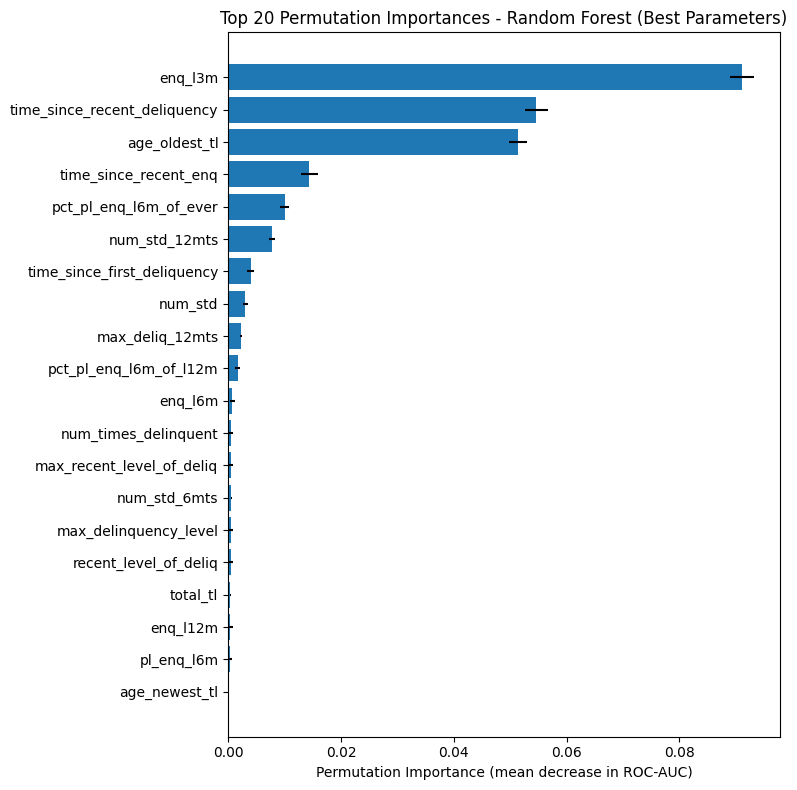


Selected 8 important features out of 85:
['enq_l3m', 'time_since_recent_deliquency', 'age_oldest_tl', 'time_since_recent_enq', 'pct_pl_enq_l6m_of_ever', 'num_std_12mts', 'time_since_first_deliquency', 'num_std']


In [22]:
# Make sure we have proper column names to label the importances with
if hasattr(X_train_processed, "columns"):
    feature_names = list(X_train_processed.columns)
else:
    feature_names = [f"feature_{i}" for i in range(X_train_processed.shape[1])]

# Built-in impurity-based importances
importances = rf_best.named_steps["model"].feature_importances_

feature_importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 20 features by impurity-based importance:")
print(feature_importance_df.head(20))

top_n = min(20, len(feature_importance_df))
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(8, 8))
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
plt.xlabel("Feature Importance")
plt.title(f"Top {top_n} Feature Importances - Random Forest (Best Parameters)")
plt.tight_layout()
plt.show()

# Permutation importance (more reliable than impurity-based importance,
# especially with correlated/one-hot/ordinal-encoded features)
perm_result = permutation_importance(
    rf_best,
    X_test_processed,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

perm_importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance_mean": perm_result.importances_mean,
        "importance_std": perm_result.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 20 features by permutation importance:")
print(perm_importance_df.head(20))

plt.figure(figsize=(8, 8))
top_perm = perm_importance_df.head(top_n)
plt.barh(top_perm["feature"][::-1], top_perm["importance_mean"][::-1],
         xerr=top_perm["importance_std"][::-1])
plt.xlabel("Permutation Importance (mean decrease in ROC-AUC)")
plt.title(f"Top {top_n} Permutation Importances - Random Forest (Best Parameters)")
plt.tight_layout()
plt.show()

# Keep the features that matter - here, anything with above-average
# permutation importance. Adjust the threshold/count to taste.
important_features = perm_importance_df.loc[
    perm_importance_df["importance_mean"] > perm_importance_df["importance_mean"].mean(),
    "feature"
].tolist()

print(f"\nSelected {len(important_features)} important features out of {len(feature_names)}:")
print(important_features)


## 13. Evaluate Regression with important features and best parameters

In [23]:
# Make sure we're working with DataFrames so we can subset by column name,
# even if the preprocessing step returned a plain numpy array
X_train_df = (
    X_train_processed if isinstance(X_train_processed, pd.DataFrame)
    else pd.DataFrame(X_train_processed, columns=feature_names)
)
X_test_df = (
    X_test_processed if isinstance(X_test_processed, pd.DataFrame)
    else pd.DataFrame(X_test_processed, columns=feature_names)
)

X_train_important = X_train_df[important_features]
X_test_important = X_test_df[important_features]

rf_best_important = Pipeline(
    steps=[
        ("model", RandomForestClassifier(
            **best_params,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ))
    ]
)

rf_best_important.fit(X_train_important, y_train)

binary_results_important = evaluate_classification(
    rf_best_important,
    X_test_important,
    y_test,
    binary=True
)

print("\n==============================")
print("Random Forest Binary Classification - Best Parameters + Important Features")
print("==============================")

for metric, value in binary_results_important.items():
    print(f"{metric}: {value}")


              precision    recall  f1-score   support

           0       0.85      0.65      0.74      2059
           1       0.88      0.96      0.92      5642

    accuracy                           0.88      7701
   macro avg       0.87      0.80      0.83      7701
weighted avg       0.87      0.88      0.87      7701


Random Forest Binary Classification - Best Parameters + Important Features
accuracy: 0.8758602778859889
f1_macro: 0.8279766879470711
precision_macro: 0.8659948784675706
recall_macro: 0.804551704855642
precision_weighted: 0.8737755797918481
recall_weighted: 0.8758602778859889
f1_weighted: 0.8702033438050928
confusion_matrix: [[1341  718]
 [ 238 5404]]
roc_auc: 0.9262678836775251
